In [2]:
# imports
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve
from src.derivatives import EuropeanCallOption, EuropeanPutOption

# Data Overview

In [7]:
from pathlib import Path
cwd = Path.cwd()
data_path = cwd / "data" / "Market_Data_BHP_prices.csv"
if not data_path.exists():
    data_path = cwd / ".." / "data" / "Market_Data_BHP_prices.csv"

df = pd.read_csv(data_path.resolve(), index_col=0, parse_dates=True, header=[0,1])

# Flatten multi-index columns and extract just BHP.AX close prices
df.columns = ['_'.join(col).strip() for col in df.columns]
close_col = [c for c in df.columns if 'Close' in c][0]
close = df[close_col].dropna()

S0 = float(close.iloc[-1])
log_returns = np.log(close / close.shift(1)).dropna()
sigma = float(log_returns.std() * np.sqrt(252))

print(f"BHP Spot Price (S0): ${S0:.2f}")
print(f"BHP Annualized Volatility (sigma): {sigma:.2%}")


BHP Spot Price (S0): $37.20
BHP Annualized Volatility (sigma): 21.75%


In [8]:
# Construct Yield Cruve from RBA Data
maturities = [0.25,2.0,3.0,5.0,10.0]
zero_rates = [0.041, 0.04536, 0.04556, 0.04621, 0.04925]
yc = YieldCurve(maturities, zero_rates)

# Sanity Checks

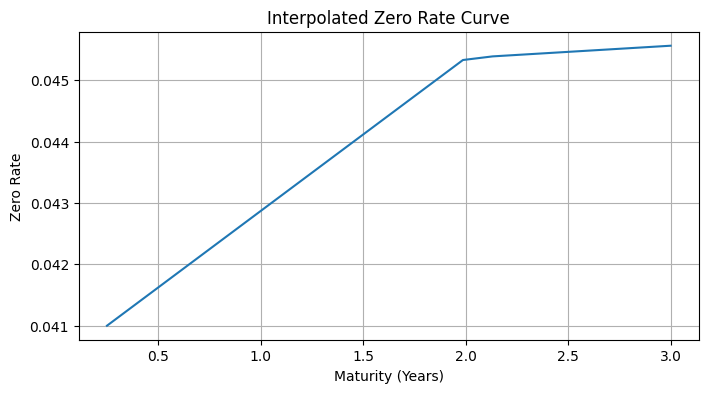

In [9]:
# sanity check on Yield Curve
test_maturities = np.linspace(0.25, 3.0, 20)
rates = [yc.get_zero_rate(T) for T in test_maturities]
dfs = [yc.get_discount_factor(T) for T in test_maturities]

plt.figure(figsize=(8,4))
plt.plot(test_maturities,rates)
plt.title("Interpolated Zero Rate Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")
plt.grid(True)
plt.show()

# Option Parameters

In [14]:
# Use BHP market data
K = round(S0)  # at-the-money strike (rounded to nearest dollar)
T = 1.0  # 1 year to maturity

print(f"Option Parameters:")
print(f" S0 = ${S0:.2f} (BHP closing Price)")
print(f" K = ${K:.2f} (at-the-money strike)")
print(f" T = {T} year")
print(f" sigma = {sigma:.2%} (historical volatility)")

call = EuropeanCallOption(S=S0, K=K, T=T, sigma=sigma, yield_curve=yc)
put = EuropeanPutOption(S=S0, K=K, T=T, sigma=sigma, yield_curve=yc)

Option Parameters:
 S0 = $37.20 (BHP closing Price)
 K = $37.00 (at-the-money strike)
 T = 1.0 year
 sigma = 21.75% (historical volatility)


# European Call and European Put Option Prices

In [15]:
# European Call Price and European Put Price 
call_price = float(round(call.price(), 4))
put_price = float(round(put.price(), 4))

print(f"The call price is ${call_price}")
print(f"The put price is ${put_price}")

The call price is $4.099
The put price is $2.3457


# Sense Checks

- Volatilty should increase both prices
- Time to maturity should increase both prices as well (calls more than puts)
- S0 should increase call price, decrease put price
- K should increase put price, decrease put price

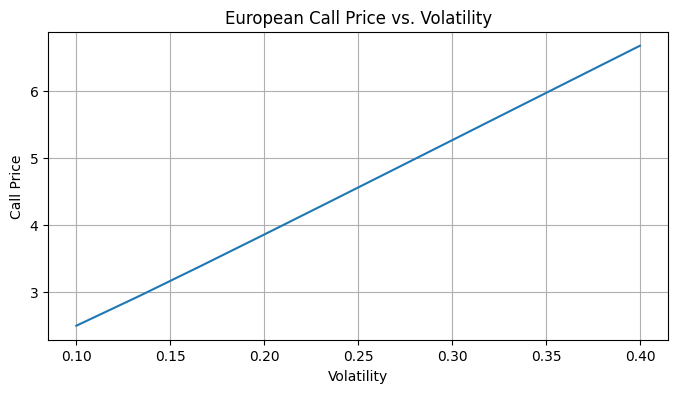

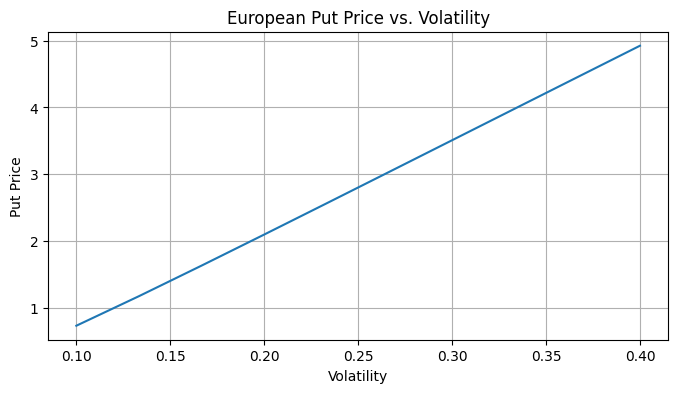

In [16]:
# Sense Checks
# 1. Volatility should increase both prices
vols = np.linspace(0.1, 0.4, 10)
call_prices = []
put_prices = []

for v in vols:
    tmp_call = EuropeanCallOption(S=S0, K=K, T=T, sigma=v, yield_curve=yc)
    tmp_put  = EuropeanPutOption( S=S0, K=K, T=T, sigma=v, yield_curve=yc)
    call_prices.append(tmp_call.price())
    put_prices.append(tmp_put.price())

plt.figure(figsize=(8,4))
plt.plot(vols, call_prices)
plt.title("European Call Price vs. Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(vols, put_prices)
plt.title("European Put Price vs. Volatility")
plt.xlabel("Volatility")
plt.ylabel("Put Price")
plt.grid(True)
plt.show()

# 2. Time to maturity should increase both prices
maturities = np.linspace(0.25, 3.0, 10)
call_prices_T = []
put_prices_T  = []

for t in maturities:
    tmp_call = EuropeanCallOption(S=S0, K=K, T=t, sigma=sigma, yield_curve=yc)